In [ ]:
%%capture
! pip install laspy 

In [1]:
# Geospatial and mapping libraries
import geopandas as gpd

# LAS (LiDAR) file handling
import laspy
from laspy import read

# Data analysis and manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Warnings management
import warnings

# File system operations
import os

# Return type hints
from typing import Tuple, List, Union


from scipy.spatial import KDTree

In [2]:
def load_and_filter_las(file_path: str, filter_class: int = 5) -> np.ndarray:
    """
    Load a .las file and return points filtered by classification.
    """
    try:
        las = laspy.read(file_path)
        mask = las.classification == filter_class
        points = np.stack([las.x[mask], las.y[mask], las.z[mask]], axis=1)
        return points
    except Exception as e:
        print(f"Error loading and filtering file: {e}")
        return None


In [3]:
def shift_points_to_origin(points) -> np.ndarray:
    """
    Shift points to the origin (0, 0, 0) by subtracting the minimum coordinates.
    """
    return points - points.min(axis=0, keepdims=True)


In [12]:
def plot_shifted_lidar(lidar_file: str):
    """
    Plot a 3D LiDAR point cloud with ground points in red and shifted coordinates.
    """
    try:
        las = laspy.read(lidar_file)
        points = np.stack([las.x, las.y, las.z], axis=1)
        classifications = las.classification

        # shift points to start from (0, 0, 0)
        points = shift_points_to_origin(points)
        ground_mask = classifications == 2
        ground_points = points[ground_mask]
        other_points = points[~ground_mask]

        file_name = os.path.splitext(os.path.basename(lidar_file))[0]

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            ground_points[:, 0],
            ground_points[:, 1],
            ground_points[:, 2],
            c="red",
            s=0.5,
            label="Ground Points",
        )

        ax.scatter(
            other_points[:, 0],
            other_points[:, 1],
            other_points[:, 2],
            c=other_points[:, 2],
            cmap="viridis",
            s=0.5,
        )

        ax.set_title("LiDAR Point Cloud Visualization (Shifted)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")  

        ax.view_init(elev=30, azim=45)  
        ax.legend(loc="upper right", markerscale=5, fontsize=10)

        plt.figtext(0.5, 0.01, f"{file_name}", ha="center", style="italic")

        plt.show()

    except Exception as e:
        print(f"Error visualizing LiDAR file: {e}")


In [5]:
def calculate_iqr_outliers(z_values: np.ndarray) -> Tuple[float, float]:
    """
    Calculate the lower and upper bounds for outliers in Z values based on the IQR method.
    """
    q1 = np.percentile(z_values, 25)  # 25th percentile (Q1)
    q3 = np.percentile(z_values, 75)  # 75th percentile (Q3)
    iqr = q3 - q1  # Interquartile range (IQR)
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    return lower_bound, upper_bound


In [6]:
def plot_z_distribution(points: np.ndarray, ax, file_name: str):
    """
    Plot the Z-value distribution for the given points on a specific subplot, with outlier boundaries.
    """
    z_values = points[:, 2]  
    
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    
    # Plot histogram
    ax.hist(z_values, bins=50, color="green", alpha=0.7, label="Z Values")
    
    # Add IQR outlier lines
    ax.axvline(lower_bound, color="red", linestyle="--", label=f"Lower: {lower_bound:.2f}")
    ax.axvline(upper_bound, color="red", linestyle="--", label=f"Upper: {upper_bound:.2f}")
    
    ax.set_title(file_name, fontsize=10)
    ax.set_xlabel("Z Value (Height)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


In [7]:
def preprocess_data(points: np.ndarray) -> np.ndarray:
    """
    Preprocess LiDAR points by shifting them and removing outliers based on the IQR method.
    """
    normalized_points = shift_points_to_origin(points)
    z_values = normalized_points[:, 2]
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    mask = (z_values >= lower_bound) & (z_values <= upper_bound)
    
    filtered_points = normalized_points[mask]
    
    return filtered_points


In [8]:
def split_dataset(data: List, train_ratio: float = 0.7) -> Tuple[List, List]:
    """
    Splits the dataset into training and testing sets based on the given ratio.
    """
    split_idx = int(len(data) * train_ratio)
    
    train_data = data[:split_idx]
    test_data = data[split_idx:]
    
    return train_data, test_data

In [9]:
def local_maxima_filter(cloud: np.ndarray, window_size: float, height_threshold: float) -> np.ndarray:
    """Detect local maxima in the point cloud with a fixed window size."""
    
    assert isinstance(cloud, np.ndarray), f"Cloud needs to be a numpy array, not {type(cloud)}"
    
    cloud = cloud[cloud[:, 2] > height_threshold]
    tree = KDTree(data=cloud)
    seen_mask = np.zeros(cloud.shape[0], dtype=bool)
    local_maxima = []

    for i, point in enumerate(cloud):
        if seen_mask[i]:
            continue
        neighbor_indices = tree.query_ball_point(point, window_size)
        highest_neighbor = neighbor_indices[cloud[neighbor_indices, 2].argmax()]
        seen_mask[neighbor_indices] = True
        seen_mask[highest_neighbor] = False 
        # This may lead to not every point being marked as seen in the end, but it does not matter,
        # because by the time the seen value is overwritten the point is already processed
        if i == highest_neighbor:
            local_maxima.append(i)
    return cloud[local_maxima]

In [10]:
plot_las_files = [f"../data/als/plot_{i:02d}.las" for i in range(1, 11)]

### Preprocessing

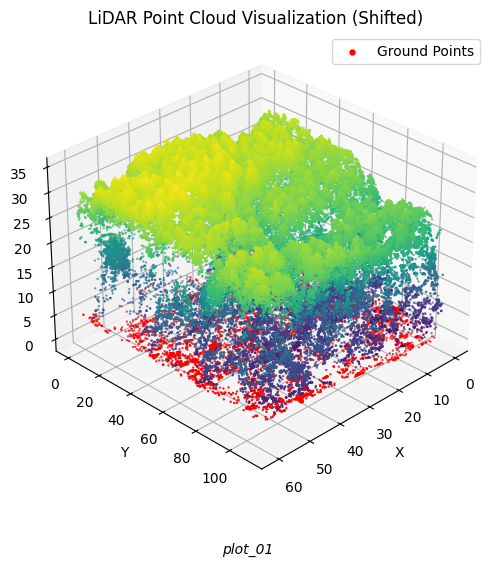

In [23]:
plot_shifted_lidar(plot_las_files[0])

Processing plot_01.las...
Processing plot_02.las...
Processing plot_03.las...
Processing plot_04.las...
Processing plot_05.las...
Processing plot_06.las...
Processing plot_07.las...
Processing plot_08.las...
Processing plot_09.las...
Processing plot_10.las...


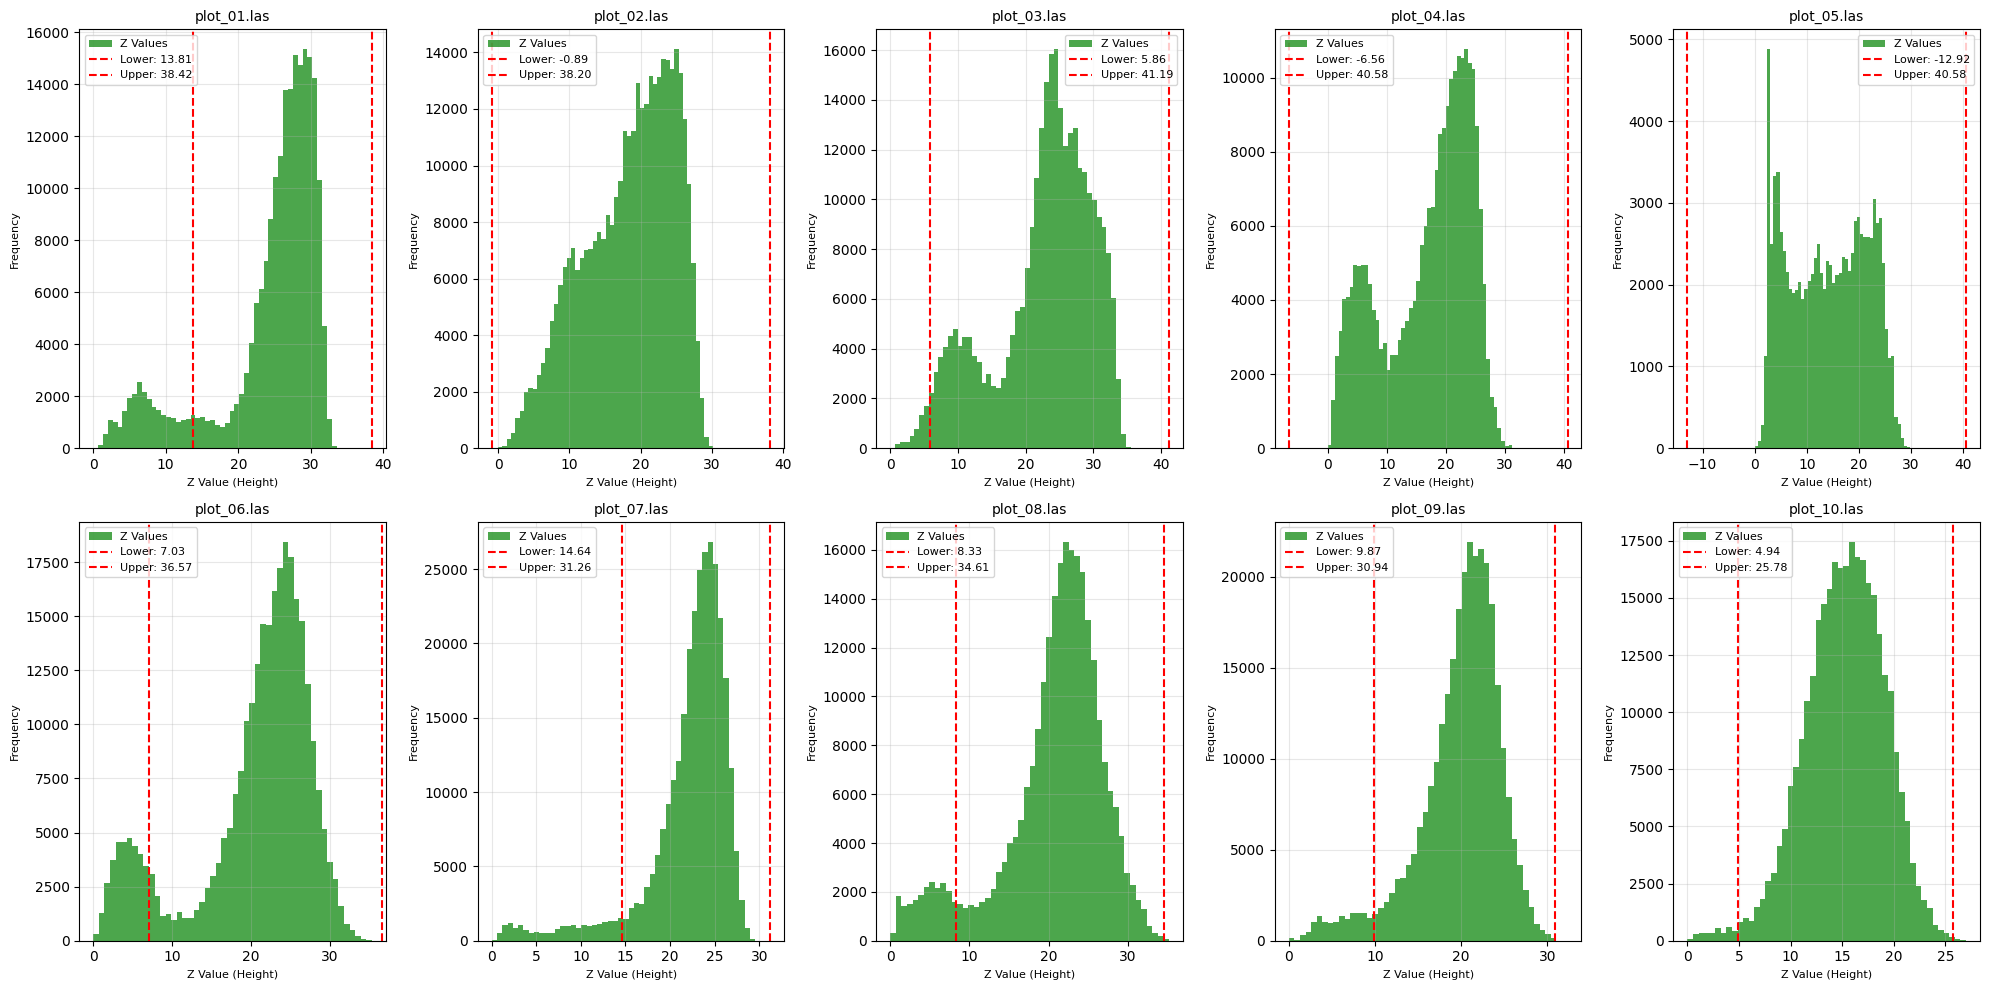

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  
axes = axes.flatten()  

for i, file_path in enumerate(plot_las_files[:10]):  
    file_name = os.path.basename(file_path)
    print(f"Processing {file_name}...")
    
    # Load and filter points
    points = load_and_filter_las(file_path, filter_class=5)
    if points is None or len(points) == 0:
        print(f"Skipping {file_name} due to an error or no valid points.")
        continue
    
    shifted_points = shift_points_to_origin(points)
    
    plot_z_distribution(shifted_points, axes[i], file_name)


plt.tight_layout()
plt.show()


In [49]:
preprocessed_data = []  

for file_path in plot_las_files:
    
    points = load_and_filter_las(file_path, filter_class=5)
    
    if points is not None and len(points) > 0:
        preprocessed_points = preprocess_data(points)
        preprocessed_data.append(preprocessed_points)  
        
    else:
        print(f"Skipping {file_path} due to no valid points.")

for i, points in enumerate(preprocessed_data):
    print(f"File {i + 1}: {len(points)} preprocessed points")


File 1: 187731 preprocessed points
File 2: 350098 preprocessed points
File 3: 290624 preprocessed points
File 4: 241722 preprocessed points
File 5: 98878 preprocessed points
File 6: 255332 preprocessed points
File 7: 283645 preprocessed points
File 8: 234435 preprocessed points
File 9: 287338 preprocessed points
File 10: 307393 preprocessed points


### Split data into train and test

In [50]:
train_ratio = 0.7
train_data, test_data = split_dataset(preprocessed_data, train_ratio)

### Detection Method

In [58]:
field_survey_gpd = gpd.read_file("../data/field_survey.geojson")

#### Local Maxima Filtering Algorithm

In [57]:
def visualize_local_maxima(cloud, local_maxima, title=None):
    """Visualize local maxima in a 2D cross-section (X-Z)."""
    #plt.scatter(cloud[:, 0], cloud[:, 2], s=1, c="black", label="Points")
    #plt.scatter(local_maxima[:, 0], local_maxima[:, 2], s=10, c="red", label="Local Maxima")
    plt.scatter(cloud[:, 0], cloud[:, 1], c=cloud[:, 2], s=2)
    plt.scatter(local_maxima[:, 0], local_maxima[:, 1], c="red", s=5)
    plt.title(title if title else "Local Maxima Detection")
    plt.xlabel("X")
    plt.ylabel("Z")
    plt.legend()
    plt.grid(True)
    plt.show()



In [70]:
window_size = 0.03 # Radius for neighbor search

for i, points in enumerate(train_data):
    print(f"Processing training file {i + 1} with {len(points)} points...")
    local_maxima_points = local_maxima_filter(points, window_size)
    print(f"Detected {len(local_maxima_points)} local maxima in training file {i + 1}.")


Processing training file 1 with 187731 points...
Detected 646 local maxima in training file 1.
Processing training file 2 with 350098 points...
Detected 435 local maxima in training file 2.
Processing training file 3 with 290624 points...
Detected 421 local maxima in training file 3.
Processing training file 4 with 241722 points...
Detected 621 local maxima in training file 4.
Processing training file 5 with 98878 points...
Detected 536 local maxima in training file 5.
Processing training file 6 with 255332 points...
Detected 446 local maxima in training file 6.
Processing training file 7 with 283645 points...
Detected 239 local maxima in training file 7.


In [71]:
cloud = train_data[6]

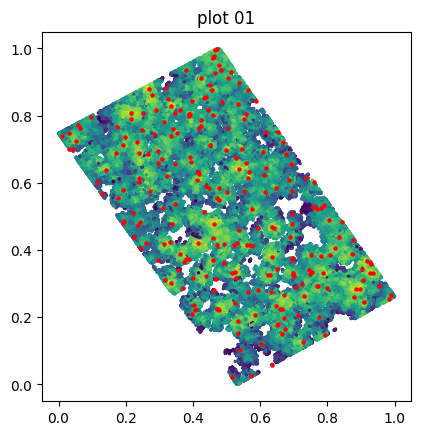

In [72]:
fig, ax = plt.subplots()
ax.scatter(cloud[:, 0], cloud[:, 1], c=cloud[:, 2], s=2)
ax.scatter(local_maxima_points[:, 0], local_maxima_points[:, 1], c="red", s=5)
ax.set_aspect("equal")

In [60]:
field_survey_gpd["plot"].value_counts().sort_index()

plot
1.0     420
2.0     365
3.0     332
4.0     261
5.0     208
6.0     290
7.0     408
8.0     341
9.0     459
10.0    518
Name: count, dtype: int64

In [19]:
local_maxima_points

array([[ 61.573,  13.483,  23.737],
       [ 68.703,  15.911,  23.633],
       [ 54.58 ,  28.936,  27.825],
       [ 82.841,  16.499,  28.02 ],
       [102.3  ,  37.11 ,  14.67 ],
       [ 65.345,   3.229,  24.144],
       [ 58.903,  43.496,  29.145],
       [ 67.825,  36.849,  24.973],
       [105.819,  43.369,  15.007],
       [ 60.763,  24.595,  27.185],
       [ 48.503,  25.685,  26.326],
       [ 84.549,  21.438,  25.589],
       [ 60.761,  25.124,  14.841],
       [ 90.553,  19.079,  26.288],
       [ 75.837,  19.438,  26.48 ],
       [ 78.513,  57.246,  26.113],
       [ 64.829,  17.882,  24.244],
       [112.156,  33.233,  26.617],
       [ 66.501,  26.835,  27.999],
       [ 85.552,  50.44 ,  26.849],
       [104.534,  48.001,  28.844],
       [ 83.19 ,  34.277,  27.755],
       [ 74.115,  23.19 ,  26.506],
       [ 79.679,  43.485,  26.821],
       [ 89.181,  49.972,  26.838],
       [ 78.856,  21.51 ,  26.362],
       [103.728,  31.975,  28.172],
       [ 99.747,  50.736,  2

In [16]:
field_survey_gpd = gpd.read_file("../data/field_survey.geojson")

In [21]:
field_survey_gpd[field_survey_gpd['plot']==7].geometry

1876    POINT (545743.181 6449357.282)
1877    POINT (545745.635 6449358.307)
1878    POINT (545747.457 6449359.498)
1879    POINT (545749.074 6449357.612)
1880    POINT (545749.287 6449360.343)
                     ...              
2279    POINT (545818.262 6449296.133)
2280    POINT (545817.772 6449298.529)
2281    POINT (545822.317 6449301.892)
2282     POINT (545828.17 6449301.203)
2283    POINT (545829.813 6449301.092)
Name: geometry, Length: 408, dtype: geometry

In [ ]:
from shapely.geometry import Point
import geopandas as gpd
from scipy.spatial import cKDTree

# Convert detected points to a GeoDataFrame
detected_points = [Point(x, y) for x, y, z in detected_data]  # Replace detected_data with your detected tree data
detected_gdf = gpd.GeoDataFrame(geometry=detected_points, crs="EPSG:your_crs")  # Use the same CRS as your ground truth

# Build a KDTree for fast spatial matching
detected_tree = cKDTree(detected_gdf.geometry.apply(lambda p: (p.x, p.y)).to_list())
ground_truth_tree = cKDTree(field_survey_gpd.geometry.apply(lambda p: (p.x, p.y)).to_list())

# Match detected trees to ground truth
dist, indices = detected_tree.query(field_survey_gpd.geometry.apply(lambda p: (p.x, p.y)).to_list(), distance_upper_bound=2)  # 2-meter tolerance
matched = dist != float('inf')  # Boolean array indicating successful matches


In [232]:
from scipy.spatial import distance_matrix

def match_candidates(ground_truth, candidates, max_distance, max_height_difference):
    """
    Match detected trees with ground truth trees using spatial and height thresholds.

    Parameters:
    - ground_truth (np.ndarray): Ground truth tree locations and heights (X, Y, Z).
    - candidates (np.ndarray): Detected tree locations and heights (X, Y, Z).
    - max_distance (float): Maximum allowed distance for matching.
    - max_height_difference (float): Maximum allowed height difference for matching.

    Returns:
    - list[dict]: Match results with classes (TP, FP, FN).
    """
    if len(ground_truth) == 0 and len(candidates) == 0:
        return []

    # Compute distance matrix between ground truth and candidates
    dist_matrix = distance_matrix(ground_truth[:, :2], candidates[:, :2])

    # Find valid matches based on distance and height thresholds
    matched_gt = np.zeros(len(ground_truth), dtype=bool)
    matched_candidates = np.zeros(len(candidates), dtype=bool)
    matches = []

    for i, gt_point in enumerate(ground_truth):
        valid_candidates = np.where((dist_matrix[i] <= max_distance) & ~matched_candidates)[0]
        if len(valid_candidates) > 0:
            closest_candidate_idx = valid_candidates[np.argmin(dist_matrix[i, valid_candidates])]
            height_diff = abs(gt_point[2] - candidates[closest_candidate_idx, 2])
            if height_diff <= max_height_difference:
                matches.append({
                    "ground_truth": tuple(gt_point),
                    "candidate": tuple(candidates[closest_candidate_idx]),
                    "distance": dist_matrix[i, closest_candidate_idx],
                    "class": "TP",  # True Positive
                })
                matched_gt[i] = True
                matched_candidates[closest_candidate_idx] = True

    # Add unmatched ground truth points as False Negatives
    matches.extend({
        "ground_truth": tuple(ground_truth[i]),
        "candidate": None,
        "class": "FN",  # False Negative
    } for i in range(len(ground_truth)) if not matched_gt[i])

    # Add unmatched candidates as False Positives
    matches.extend({
        "ground_truth": None,
        "candidate": tuple(candidates[j]),
        "class": "FP",  # False Positive
    } for j in range(len(candidates)) if not matched_candidates[j])

    return matches


In [233]:
def calculate_metrics(matches):
    """
    Calculate precision, recall, and F1-score from matches.

    Parameters:
    - matches (list[dict]): Match results with "class" field.

    Returns:
    - dict: Precision, recall, and F1-score.
    """
    if not matches:
        return {"precision": 0, "recall": 0, "f1_score": 0}

    tp = sum(1 for m in matches if m["class"] == "TP")
    fp = sum(1 for m in matches if m["class"] == "FP")
    fn = sum(1 for m in matches if m["class"] == "FN")

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0

    return {"precision": precision, "recall": recall, "f1_score": f1_score}


In [236]:
# Parameters
window_size = 3
height_threshold = 2
max_distance = 5  # Maximum allowed distance for matching
max_height_difference = 3  # Maximum allowed height difference

# Extract x and y coordinates from the geometry column
ground_truth_gdf["geometry.x"] = ground_truth_gdf.geometry.x
ground_truth_gdf["geometry.y"] = ground_truth_gdf.geometry.y

for plot_id, points in enumerate(train_data, start=1):
    print(f"Processing Plot {plot_id}...")
    
    # Detect local maxima (trees)
    detected_trees = local_maxima_filter(points, window_size, height_threshold)

    # Get ground truth for the plot
    ground_truth_trees = ground_truth_gdf[ground_truth_gdf["plot"] == plot_id]
    ground_truth_array = ground_truth_trees[["geometry.x", "geometry.y", "height"]].to_numpy()

    if len(ground_truth_array) == 0:
        print(f"No ground truth data for Plot {plot_id}. Skipping evaluation.")
        continue

    # Match detected trees with ground truth
    matches = match_candidates(ground_truth_array, detected_trees, max_distance, max_height_difference)

    # Calculate metrics
    metrics = calculate_metrics(matches)
    print(f"Plot {plot_id} - Precision: {metrics['precision']:.2f}, Recall: {metrics['recall']:.2f}, F1-Score: {metrics['f1_score']:.2f}")



Processing Plot 1...
Plot 1 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 2...
Plot 2 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 3...
Plot 3 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 4...
Plot 4 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 5...
Plot 5 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 6...
Plot 6 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 7...
Plot 7 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00


In [209]:
window_size = 3
height_threshold = 2  # Assuming the height dimension is Z (index 2)
cloud = train_data[0]
local_maxima = local_maxima_filter(cloud, window_size, height_threshold)

In [210]:
len(local_maxima)

243

plot
10.0    518
9.0     459
1.0     420
7.0     408
2.0     365
8.0     341
3.0     332
6.0     290
4.0     261
5.0     208
Name: count, dtype: int64

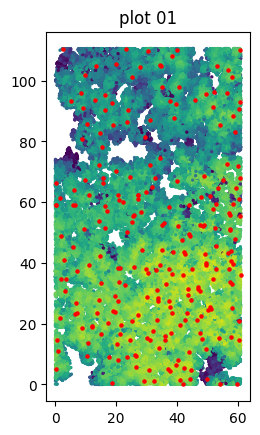

In [237]:
fig, ax = plt.subplots()
ax.scatter(cloud[:, 0], cloud[:, 1], c=cloud[:, 2], s=2)
ax.scatter(local_maxima[:, 0], local_maxima[:, 1], c="red", s=5)
ax.set_title('plot 01')
ax.set_aspect("equal")

#### Convert Point Cloud to Voxel Grid

#### Advanced DNN architecture

### Comparison